## Recommender System for Cyberattack Incidents
Can we predict the values of an incident using data of structuraly similar incidents?
We will use MAE as a proof of properly obtained prediction.

### Context
This notebook applies collaborative filtering, a technique typically used to 
recommend products or movies, to a domain of cybersecurity incidents. The 
underlying idea is adapted: instead of recommending items to users based on 
shared preferences, we retrieve historically similar incidents for a given 
company profile. A security analyst need the system for a company under 
attack, where they would receive a ranked list of comparable past incidents.

### Research question
Does structural similarity between companies (size, market exposure, 
volatility) provide sufficient signal to retrieve incidents that are 
meaningfully comparable, sharing the same attack vector and industry?

This question is answered in two parts across this notebook:
- **Part 1 (MAE analysis):** Can similar incidents predict each other's numerical outcomes (loss, downtime, recovery time)?
- **Part 2 (Precision/Recall analysis):** Can the similarity function retrieve incidents from the same attack category and industry without being told those categories explicitly?

Part 1 assumes that similar incidents require of similar outcomes. Failing Part 1 does not invalidate Part 2.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error

# 1. Setup & Data Loading

Providing the dataset
Merge the csv's
Stablish the features we are interested in:
- There are all the numerical fields non-NaN, such that an enterprise dispose without being attacked.
- Some interesting categorical information

In [3]:
# Extract CSV's to PD's dataframes
df_financial = pd.read_csv("data/raw/financial_impact.csv")
df_incidents = pd.read_csv("data/raw/incidents_master.csv")
df_market = pd.read_csv("data/raw/market_impact.csv")

df_merged = df_incidents.merge(df_financial, on='incident_id', how='inner').merge(df_market, on='incident_id', how='inner') # master

MIN_VALID_NEIGHBOURS = 4

"""provided_features = [
    'company_revenue_usd',
    'employee_count',
    'pre_incident_volatility_30d',  # baseline, known before
    'market_cap_at_disclosure',     # judgment call — you decide
    # encoded categoricals:
    #'attack_vector_primary_enc',
    #'industry_primary_enc',
    #'data_type_enc',
    #'attribution_confidence_enc',
]"""

provided_features = [
    'company_revenue_usd',
    'employee_count',
    'pre_incident_volatility_30d',
    'market_cap_at_disclosure',
    'volume_avg_30d_baseline',
]

predict_features = [
    'days_to_price_recovery',
    'total_loss_usd',
    'downtime_hours',
    'abnormal_return_30d',
    #'car_0_to_30',
]

cat_features = [
    #'attack_vector_primary',
    'industry_primary',
    #'data_type',
]

df_merged.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker_x,incident_date,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0213-001,Stuttgart Distribution SE,7.334128e+08,DE,44-45,NaN,8169,True,STUT.DE,2021-02-13,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2025-0529-001,BazaarBrand Stores Co.,3.991403e+10,US,44-45,NaN,776266,True,BAZA,2025-05-29,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
from utils import define_feature_types
num_cols, cat_cols = define_feature_types(df_merged)

# 2. First Approach - Baseline Pearson

KNN is a non-parametric, lazy learner: it has no learned 
parameters and does not "train" in any meaningful sense. Every prediction 
is made directly from the pool of known incidents at query time.

This is why we follow a data maximization approach. For each incident, temporarily remove it from the pool, predict its value from the remaining incidents, then compare to its known value. This maximises pool size while guaranteeing the target never retrieves itself.

**What do we use?** MAE (Mean Absolute Error) across all predict features, 
compared against a naive base case using the global mean.

## Continuous data only

We begin with the simplest possible similarity measure: Pearson correlation 
on continuous features only. This establishes a baseline before introducing 
any categorical information.

In [5]:
def predictions_performance_numerical(df, predict_features, needed_features, k_similar=5):
    predictions = {ftr: [] for ftr in predict_features}
    actuals     = {ftr: [] for ftr in predict_features}

    for idx in df.index:
        
        target = df.loc[idx, needed_features]
        df_pool = df.drop(index=idx)

        similarity = df_pool[needed_features].corrwith(target, axis=1)
        top_idx = similarity.nlargest(k_similar*2).index

        for ftr in predict_features:
            if ftr not in df.columns:
                print(f"Feature '{ftr}' not found in DataFrame. Skipping.")
                continue
            
            actual = df.loc[idx, ftr]
            if pd.isna(actual):
                continue

            
            # predict outcome as weighted mean of neighbours
            try:
                neighbour_outcomes = df.loc[top_idx, ftr].dropna().head(k_similar) # only keep the top k most similar neighbours with a value for the feature we want to predict
                weights = similarity[neighbour_outcomes.index]
                
                #print("===\n",similarity)
                # only keep positive correlations, in order to avoid making predictions based on negatively correlated neighbours, which would be counterintuitive and likely lead to worse predictions          
                weights = weights[weights > 0]

                if len(weights) < MIN_VALID_NEIGHBOURS:
                    continue

                """ We compute the average of the most k rellevant neighbours for some variable ftr.
                Each value of ftr is weighted by how similar the neighbour is to the target."""
                predicted = np.average(neighbour_outcomes[weights.index], 
                                    weights=weights)
                #print("==\n", predicted,"\n", actual)
                """We just do a weighted average without substracting the individual neighbour's mean,
                because we are not working with ratings, and each feature is on a different scale,
                so we cannot assume that the mean is representative. Moreover, we work with unbiased data."""

                predictions[ftr].append(predicted)
                actuals[ftr].append(actual)
            except ZeroDivisionError as e:
                continue
    
    maes = {}
    for ftr in predict_features:
        if predictions[ftr]:
            mae = mean_absolute_error(actuals[ftr], predictions[ftr])
            maes[ftr] = mae
            print(f"MAE: {mae:.10f} {ftr}")
        else:
            print(f"No predictions made for '{ftr}'.")
    return maes

maes = {}
for k in range(2,12,2):
    print(f"=== K={k} ===")
    maes[k] = predictions_performance_numerical(df_merged, predict_features, provided_features, k_similar=k)
    

=== K=2 ===
No predictions made for 'days_to_price_recovery'.
No predictions made for 'total_loss_usd'.
No predictions made for 'downtime_hours'.
No predictions made for 'abnormal_return_30d'.
=== K=4 ===
MAE: 93.3221995715 days_to_price_recovery
MAE: 112822439.9143292755 total_loss_usd
MAE: 83.3733645474 downtime_hours
MAE: 0.0222090357 abnormal_return_30d
=== K=6 ===
MAE: 91.0305169994 days_to_price_recovery
MAE: 107556318.9995984882 total_loss_usd
MAE: 90.8070286289 downtime_hours
MAE: 0.0211328952 abnormal_return_30d
=== K=8 ===
MAE: 90.3044007519 days_to_price_recovery
MAE: 107527450.4421934187 total_loss_usd
MAE: 98.9884554338 downtime_hours
MAE: 0.0210286766 abnormal_return_30d
=== K=10 ===
MAE: 91.0231990686 days_to_price_recovery
MAE: 109719439.2211164832 total_loss_usd
MAE: 94.6304680997 downtime_hours
MAE: 0.0210065485 abnormal_return_30d


### Plot: MAE vs K plot

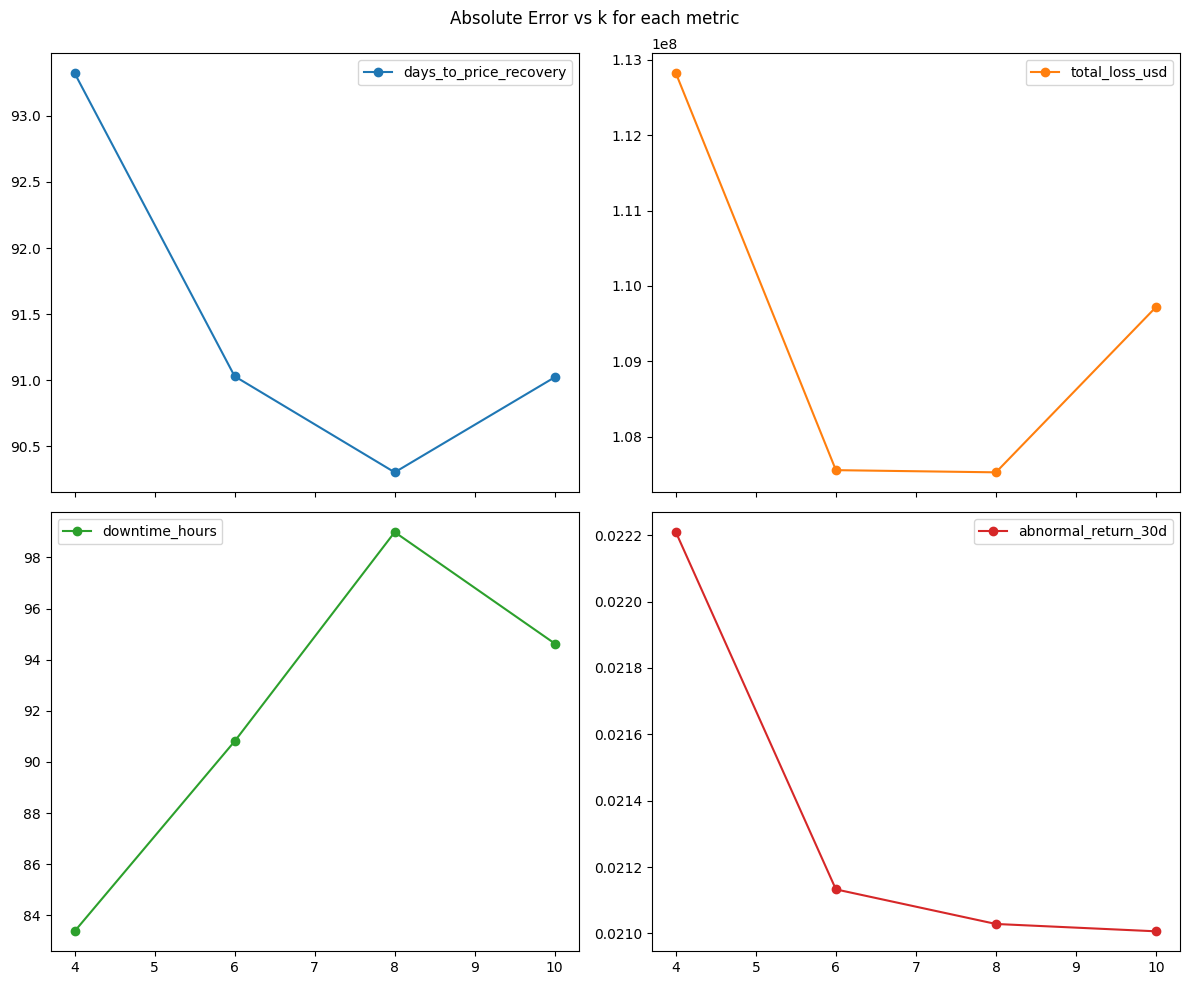

In [ ]:
# MAE vs K plot
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(maes).

df.plot(
    subplots=True,
    layout=(2, 2), 
    figsize=(12, 10),
    marker='o', 
    title="Absolute Error vs k for each metric"
)

plt.tight_layout() # Prevents labels overlapping
plt.show()

As you can see, we are in trouble, since computing the mean absolute error selecting all the candidates is more precise than selecting the most similar. This could mean that the data used for selecting k similar is not meaningful correlated with the features we want to predict.

In [7]:
from sklearn.dummy import DummyRegressor

for ftr in predict_features:
    col = df_merged[ftr].dropna()
    # naive baseline: always predict the median
    naive_mae = (col - col.median()).abs().mean()
    print(f'{ftr}: naive MAE = {naive_mae:.4f}')

days_to_price_recovery: naive MAE = 79.8639
total_loss_usd: naive MAE = 76239829.6597
downtime_hours: naive MAE = 75.4224
abnormal_return_30d: naive MAE = 0.0194


Any useful similarity function must beat this foundation, otherwise the neighbourhood adds no signal beyond what the marginal distribution already provides.

### Correlation matrix

In [8]:
# Source - https://stackoverflow.com/a/50703596
# Posted by joelostblom, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-23, License - CC BY-SA 4.0

import pandas as pd
import numpy as np

rs = np.random.RandomState(0)
df = pd.DataFrame(rs.rand(10, 10))
corr = df_merged[provided_features+predict_features].corr()
corr.style.background_gradient(cmap='coolwarm')



,company_revenue_usd,employee_count,pre_incident_volatility_30d,market_cap_at_disclosure,volume_avg_30d_baseline,days_to_price_recovery,total_loss_usd,downtime_hours,abnormal_return_30d
company_revenue_usd,1.000000,0.818477,-0.096564,0.919401,-0.038500,0.040642,0.199376,-0.034206,-0.044426
employee_count,0.818477,1.000000,-0.048405,0.793216,-0.057195,0.038270,0.108229,-0.048387,-0.040585
pre_incident_volatility_30d,-0.096564,-0.048405,1.000000,-0.090206,0.065670,0.014378,-0.012511,0.003372,0.004502
market_cap_at_disclosure,0.919401,0.793216,-0.090206,1.000000,-0.042474,0.033377,0.173857,-0.071857,-0.042653
volume_avg_30d_baseline,-0.038500,-0.057195,0.065670,-0.042474,1.000000,-0.045587,0.131459,-0.073030,0.065777
days_to_price_recovery,0.040642,0.038270,0.014378,0.033377,-0.045587,1.000000,-0.092385,-0.017354,-0.609359
total_loss_usd,0.199376,0.108229,-0.012511,0.173857,0.131459,-0.092385,1.000000,-0.073497,0.092952
downtime_hours,-0.034206,-0.048387,0.003372,-0.071857,-0.073030,-0.017354,-0.073497,1.000000,0.042922
abnormal_return_30d,-0.044426,-0.040585,0.004502,-0.042653,0.065777,-0.609359,0.092952,0.042922,1.000000


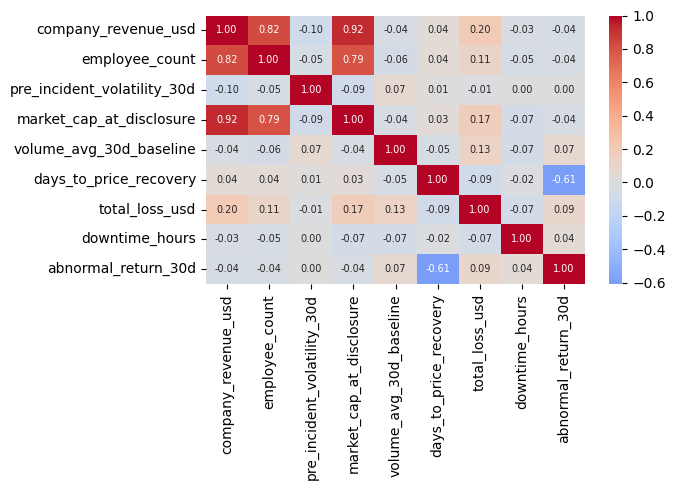

In [16]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, annot=True, fmt='.2f', annot_kws={'size':7})
plt.tight_layout()
plt.savefig('heatmap.pdf')

### Pearson's Similarity Failing

The heatmap confirms both hypotheses. Among provided features, 
`company_revenue_usd`, `employee_count`, and `market_cap_at_disclosure` 
are strongly correlated. They all measure company scale and carry redundant information. Moreover, provided features show weak correlation with predict features, meaning company profile alone is a poor predictor of incident outcomes.

This motivated us to include categorical data into our analysis, trying to balance the weight provided by the numerical data. Since with only 3–5 features, the correlation between any two rows approaches +- 1.0 mathematically. 

## Adding categorical data



### Binary categorical features

First step is finding a way to take profit of the categorical feature, but without introducing bias. Categorical features cannot be used directly in Pearson correlation, assigning arbitrary integers to categories (ransomware=1, phishing=2) would imply a false relationship. Instead, we apply one-hot encoding: each category value becomes a binary column (0 or 1).


In [9]:
# Encode and join
df_encoded = pd.get_dummies(df_merged[cat_features], dtype=float)
df_merged = df_merged[num_cols]

df_merged = pd.concat([df_merged, df_encoded], axis=1)

# Take all the values found on the categorical features and add them to the list, so they can be used as binary features
encoded_cols = df_encoded.columns.tolist()
#provided_features = provided_features + encoded_cols

encoded_cols

['industry_primary_11',
 'industry_primary_21',
 'industry_primary_22',
 'industry_primary_23',
 'industry_primary_31-33',
 'industry_primary_42',
 'industry_primary_44-45',
 'industry_primary_48-49',
 'industry_primary_51',
 'industry_primary_52',
 'industry_primary_53',
 'industry_primary_54',
 'industry_primary_55',
 'industry_primary_56',
 'industry_primary_62',
 'industry_primary_71',
 'industry_primary_72',
 'industry_primary_81']

### Pearson's Similarity Failing

In [ ]:
# For a single predict feature, check: are similar incidents 
# actually similar in outcome?

ftr = 'days_to_price_recovery'
target_idx = df_merged[ftr].dropna().index[0] # arbitrary target
target = df_merged.loc[target_idx, provided_features + encoded_cols]
df_pool = df_merged.drop(index=target_idx)

similarity = df_pool[provided_features + encoded_cols].corrwith(target, axis=1)
top_idx = similarity.nlargest(100).index

print(f"Target value: {df_merged.loc[target_idx, ftr]:.1f}")
print(f"Top 100 neighbours' values:")
print(df_merged.loc[top_idx, ftr].dropna().values)
print(f"\nTheir similarity scores:")
print(similarity[top_idx].values)

Target value: 255.0
Top 100 neighbours' values:
[ 49.  55. 122.  37.  19.  30.  43. 324.  45.  45.  53.  80.   8.  32.
   8. 290.  53. 101. 159. 284.  42. 115.  53. 298. 283. 264.  54. 226.
  33. 157. 221. 165. 335.  28.   9. 282. 298.  31.  10.  53.  28.  43.
 126. 301. 274. 171.  15.  32.  36.   5.  35.  49. 335.  56.  55. 145.
  41.  20.  28.  39. 325. 313. 284.  43.   7. 276. 164. 192. 240.  49.
  28. 320.  17.  43.  57.  43.  28.  70. 101.  59.  32. 206.  60. 291.
  24.  13.  13. 184.  28.] 
 89

Their similarity scores:
[0.99999998 0.99999935 0.99999926 0.99999819 0.99999809 0.99999751
 0.99999702 0.99998895 0.99998751 0.99998505 0.99998425 0.99998291
 0.9999812  0.99997729 0.99997656 0.99997642 0.99997404 0.99996932
 0.99996353 0.99995042 0.99994904 0.99994825 0.99994633 0.99993783
 0.9999228  0.99992071 0.99991681 0.99991143 0.99991058 0.99989818
 0.99989597 0.99989544 0.99988899 0.99988282 0.99988037 0.9998667
 0.99986313 0.99986246 0.99985633 0.99984828 0.99984699 0.99984613


In [11]:
target = df_merged.loc[target_idx, provided_features + encoded_cols]
print("NaN count in target:", target.isna().sum())
print("Constant encoded cols (with no members):", (df_merged[encoded_cols].std() == 0).sum())

# Check how many provided_features are actually non-NaN for the target
print(target.dropna())

NaN count in target: 0
Constant encoded cols (with no members): 0
company_revenue_usd            2.480619e+10
employee_count                 7.136900e+04
pre_incident_volatility_30d    2.770500e-02
market_cap_at_disclosure       1.181988e+11
volume_avg_30d_baseline        1.978229e+07
industry_primary_11            0.000000e+00
industry_primary_21            0.000000e+00
industry_primary_22            0.000000e+00
industry_primary_23            0.000000e+00
industry_primary_31-33         0.000000e+00
industry_primary_42            0.000000e+00
industry_primary_44-45         0.000000e+00
industry_primary_48-49         0.000000e+00
industry_primary_51            1.000000e+00
industry_primary_52            0.000000e+00
industry_primary_53            0.000000e+00
industry_primary_54            0.000000e+00
industry_primary_55            0.000000e+00
industry_primary_56            0.000000e+00
industry_primary_62            0.000000e+00
industry_primary_71            0.000000e+00
industry_p

After getting those high similarity values yet, we detected no NaN's on the target, neither categorical columns with no members, but the target only belongs to a singles primary industry. This happens because of how Person's is using distances in order to claim who is similar. 

# 3. Second Approach - Combined Similarity (Pearson + Jaccard)

Since Pearson's is failling on the computation of similarities due to the several number of encoded features (large number of shared zeros are only similar noise), we will apply different similarity algorithms for those different types of data.

Jaccard similarity is a statistical measure used to quantify how similar two sets are, we are interested in discovering if two different entries happend in the same category (as belonging to the same industry).

SUMMARY
- **Pearson on continuous features**: Captures structural similarity 
  between companies (size, market exposure, volatility)
- **Jaccard on encoded categorical features**: Captures incident-type 
  similarity (same attack vector, same industry sector)

Alpha values:
- `alpha = 1.0` -> pure Pearson (company profile only)
- `alpha = 0.0` -> pure Jaccard (incident type only)  
- `alpha = 0.5` -> equal weight to both

In [12]:
def compute_similarity(df, target_idx, continuous_features, encoded_features, alpha=0.5):
    """
    Compute similarity between a target instance and all other instances in the dataset.
    :param df: DataFrame containing the data
    :param target_idx: Index of the target instance
    :param continuous_features: List of continuous features
    :param encoded_features: List of encoded categorical features
    :param alpha: weight of continuous similarity vs categorical similarity

    Two trojan attacks on industry 51? -> Jaccard = 1.0
    A trojan on industry 51 vs a phishing on industry 52? -> Jaccard = 0.0.
    
    :return: similarity combined notes for the same index based on both continuous and categorical features
    """
    target = df.loc[target_idx]
    df_pool = df.drop(index=target_idx)
    
    # continuous similarity: Pearson on numeric features only
    sim_continuous = df_pool[continuous_features].corrwith(
        target[continuous_features], axis=1
    )
    
    # categorical similarity: Jaccard on encoded features
    target_encoded = target[encoded_features].values
    pool_encoded = df_pool[encoded_features].values
    
    intersection = (pool_encoded * target_encoded).sum(axis=1)
    union = ((pool_encoded + target_encoded) > 0).sum(axis=1)
    sim_categorical = pd.Series(
        np.where(union > 0, intersection / union, 0),
        index=df_pool.index
    )
    
    combined = alpha * sim_continuous + (1 - alpha) * sim_categorical
    return combined

For predicting total_loss_usd, what matters more, that two companies are structurally similar (size, market cap) or that two incidents are categorically similar (same industry)? This decisions fall into the variable alpha.

In [13]:
target_idx = df_merged[predict_features].dropna(subset=['total_loss_usd']).index[0]
actual_value = df_merged.loc[target_idx, 'total_loss_usd']

# Compute similarity with the new function
similarity = compute_similarity(df_merged, target_idx, provided_features, encoded_cols, alpha=0.5)

# Get top K
ftr = 'total_loss_usd'
top_idx = similarity.nlargest(10 * 2).index
neighbour_outcomes = df_merged.loc[top_idx, ftr].dropna().head(10)
weights = similarity[neighbour_outcomes.index]
weights = weights[weights > 0]

predicted = np.average(neighbour_outcomes[weights.index], weights=weights)

print(f"Actual:    {actual_value:,.2f}")
print(f"Predicted: {predicted:,.2f}")
print(f"Error:     {abs(actual_value - predicted):,.2f}")
print(f"\nTop neighbours similarity scores:")
print(similarity[neighbour_outcomes.index])

Actual:    71,616,414.97
Predicted: 59,621,543.92
Error:     11,994,871.05

Top neighbours similarity scores:
125    0.999956
246    0.999938
67     0.999923
128    0.999908
127    0.999887
239    0.999853
124    0.999824
223    0.999815
101    0.999811
25     0.999789
dtype: float64


The single-example shows that even with the corrected similarity function, similarity scores remain near 1.0. So the Jaccard component assigns full score to incidents sharing the same industry, producing many ties.

In [14]:
def measure_predictions_performance(df, predict_features, needed_features, k_similar=5, alpha=0.5):
    predictions = {ftr: [] for ftr in predict_features}
    actuals     = {ftr: [] for ftr in predict_features}
    for idx in df.index:
        
        similarity = compute_similarity(df_merged, idx, needed_features, encoded_cols, alpha=alpha)
        top_idx = similarity.nlargest(k_similar*2).index

        for ftr in predict_features:
            if ftr not in df.columns:
                print(f"Feature '{ftr}' not found in DataFrame. Skipping.")
                continue
            
            actual = df.loc[idx, ftr]
            if pd.isna(actual):
                continue
                
            # remove target from pool
            target = df.loc[idx, needed_features]
            df_pool = df.drop(index=idx)
            
            # predict outcome as weighted mean of neighbours
            try:
                neighbour_outcomes = df.loc[top_idx, ftr].dropna().head(k_similar) # only keep the top k most similar neighbours with a value for the feature we want to predict
                weights = similarity[neighbour_outcomes.index]
                
                #print("===\n",similarity)
                # only keep positive correlations, in order to avoid making predictions based on negatively correlated neighbours, which would be counterintuitive and likely lead to worse predictions          
                weights = weights[weights > 0]

                if len(weights) < MIN_VALID_NEIGHBOURS:
                    continue

                """ We compute the average of the most k rellevant neighbours for some variable ftr.
                Each value of ftr is weighted by how similar the neighbour is to the target."""
                predicted = np.average(neighbour_outcomes[weights.index], 
                                    weights=weights)
                #print("==\n", predicted,"\n", actual)
                """We just do a weighted average without substracting the individual neighbour's mean,
                because we are not working with ratings, and each feature is on a different scale,
                so we cannot assume that the mean is representative. Moreover, we work with unbiased data."""

                predictions[ftr].append(predicted)
                actuals[ftr].append(actual)
            except ZeroDivisionError as e:
                continue
        
    maes = {}
    for ftr in predict_features:
        if predictions[ftr]:
            mae = mean_absolute_error(actuals[ftr], predictions[ftr])
            maes[ftr] = mae
            print(f"MAE: {mae:.4f} {ftr}")
        else:
            print(f"No predictions made for '{ftr}'.")
    return maes

#measure_predictions_performance(df_merged, predict_features, provided_features, k_similar=10, alpha=0.5)

results = {}
k_values = [10]
alpha_values = np.arange(0.0, 1.1, 0.25)
for k in k_values:
    results[k] = {}
    for alpha in alpha_values:
        print(f"Evaluating for alpha={alpha:.2f}...")
        results[k][alpha] = measure_predictions_performance(df_merged, predict_features, provided_features, k_similar=k, alpha=alpha)
    

Evaluating for alpha=0.00...
MAE: 92.1949 days_to_price_recovery
MAE: 116596294.0575 total_loss_usd
MAE: 116.3042 downtime_hours
MAE: 0.0218 abnormal_return_30d
Evaluating for alpha=0.25...
MAE: 88.9030 days_to_price_recovery
MAE: 112788323.0395 total_loss_usd
MAE: 92.5186 downtime_hours
MAE: 0.0211 abnormal_return_30d
Evaluating for alpha=0.50...


KeyboardInterrupt: 

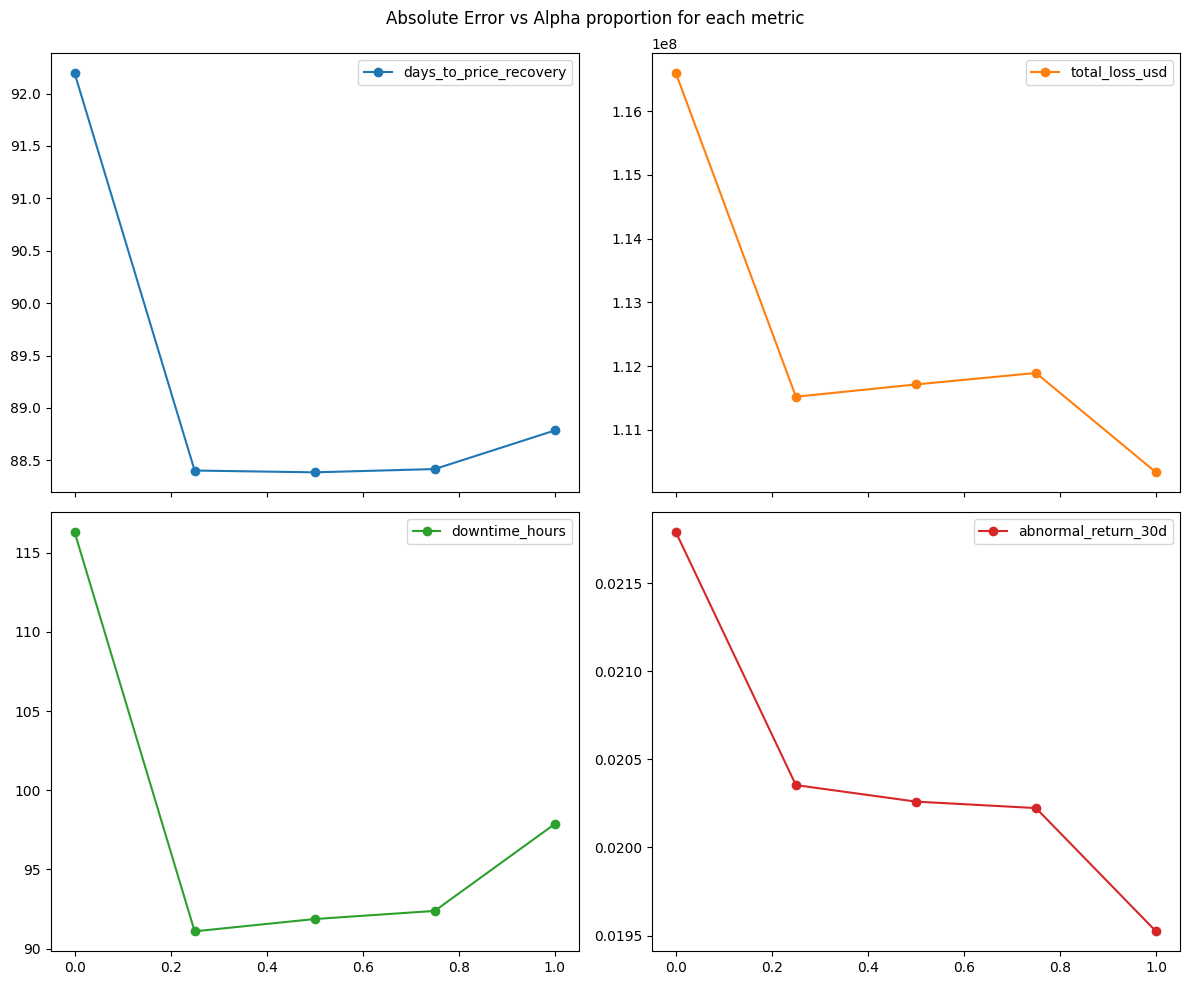

In [ ]:
# MAE vs alpha plot
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results[10]).T

df.plot(
    subplots=True,
    layout=(2, 2), 
    figsize=(12, 10),
    marker='o', 
    title="Absolute Error vs Alpha proportion for each metric"
)

plt.tight_layout() # Prevents labels overlapping
plt.show()

### Conclusion - Numerical prediction

Introducing categorical similarity via Jaccard does not improve MAE over the naive baseline on any feature. Even so, alpha = 0.25 performs best overall, suggesting categorical information marginally helps, but not enough to overcome the fundamental variance problem.

**The core finding is a domain property, not a model failure:** cyberattack financial outcomes are driven by incident-specific factors, as ransom negotiation decisions, insurance coverage, legal exposure, action speed.

# Part 2 - Retrieval Evaluation: Precision, Recall, Average Precision

Does the similarity function retrieve structurally relevant incidents?
We use same attack type, same industry as a grown truth.

**Relevance definition:** an incident is considered relevant to a query if it shares the same "attack_vector_primary" AND "industry_primary". This definition captures whether retrieved incidents are genuinely comparable from an operational security perspective, independent of their numerical outcomes.

**Why this matters for the research question?** if Precision and Recall 
are meaningful, it implies that companies with similar structural 
profiles tend to attract similar attack types


In [ ]:
def get_relevant(df_raw, idx):
    """
    Returns the set of incident indices that share the same
    attack vector and industry as the query incident `idx`.
    These are considered 'ground truth relevant' for retrieval.
    """
    same_attack   = df_raw['attack_vector_primary'] == df_raw.loc[idx, 'attack_vector_primary']
    same_industry = df_raw['industry_primary']      == df_raw.loc[idx, 'industry_primary']
    is_not_self   = df_raw.index != idx
    return set(df_raw[same_attack & same_industry & is_not_self].index)


def average_precision(ranked, relevant):
    """
    AP = sum_{k=1}^{N} P(k) * rel(k) / |relevant|
    ranked   : ordered list of retrieved incident indices
    relevant : set of ground truth relevant indices
    """
    hits, ap = 0, 0.0
    for k, idx in enumerate(ranked, start=1):
        if idx in relevant:
            hits += 1
            ap   += hits / k          # P(k) * rel(k), since rel(k)=1
    return ap / len(relevant)


def precision_recall_f1(ranked, relevant):
    """
    Computes P, R, F1 at every K from 1 to len(ranked).
    Returns three lists of length len(ranked).
    """
    precisions, recalls, f1s = [], [], []
    retrieved = set()

    for k, idx in enumerate(ranked, start=1):
        retrieved.add(idx)
        tp        = len(retrieved & relevant)
        p         = tp / k
        r         = tp / len(relevant)
        f1        = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return precisions, recalls, f1s


def retrieval_metrics(df_merged_raw, df_sim, provided_features, encoded_cols, k_max=20):
    """
    Evaluates the recommender using P, R, F1, and AP across all queries.
    Skips incidents with no relevant neighbours (P/R undefined).
    Returns a metrics DataFrame indexed by K, and a list of AP scores.
    """
    # accumulators: one list per K position
    all_p  = {k: [] for k in range(1, k_max + 1)}
    all_r  = {k: [] for k in range(1, k_max + 1)}
    all_f1 = {k: [] for k in range(1, k_max + 1)}
    ap_scores = []

    for idx in df_sim.index:

        relevant = get_relevant(df_merged_raw, idx)
        if not relevant:
            continue                  # no ground truth → skip

        similarity = compute_similarity(df_sim, idx, provided_features, encoded_cols, alpha=1.0)
        ranked     = list(similarity.nlargest(k_max).index)

        # AP for this query
        ap_scores.append(average_precision(ranked, relevant))

        # P, R, F1 at each K for this query
        p_list, r_list, f1_list = precision_recall_f1(ranked, relevant)
        for k in range(1, k_max + 1):
            all_p[k].append(p_list[k - 1])
            all_r[k].append(r_list[k - 1])
            all_f1[k].append(f1_list[k - 1])

    metrics_df = pd.DataFrame({
        'Precision': [np.mean(all_p[k])  for k in range(1, k_max + 1)],
        'Recall':    [np.mean(all_r[k])  for k in range(1, k_max + 1)],
        'F1':        [np.mean(all_f1[k]) for k in range(1, k_max + 1)],
    }, index=pd.RangeIndex(1, k_max + 1, name='K'))

    return metrics_df, ap_scores

In [ ]:
df_merged_raw = df_incidents.merge(df_financial, on='incident_id', how='inner').merge(df_market, on='incident_id', how='inner') # master

metrics_df, ap_scores = retrieval_metrics(
    df_merged_raw  = df_merged_raw,
    df_sim         = df_merged,       # numeric + encoded version
    provided_features = provided_features,
    encoded_cols   = encoded_cols,
    k_max          = 20
)

In [ ]:
print("=== Mean Average Precision (MAP) ===")
print(f"MAP: {np.mean(ap_scores):.4f}")
print(f"Median AP: {np.median(ap_scores):.4f}")
print()
print("=== Metrics per K ===")
print(metrics_df.round(4))

=== Mean Average Precision (MAP) ===
MAP: 0.0106
Median AP: 0.0000

=== Metrics per K ===
    Precision  Recall      F1
K                            
1      0.0169  0.0025  0.0042
2      0.0186  0.0057  0.0079
3      0.0158  0.0079  0.0092
4      0.0178  0.0098  0.0111
5      0.0203  0.0128  0.0140
6      0.0198  0.0143  0.0150
7      0.0194  0.0161  0.0159
8      0.0182  0.0183  0.0164
9      0.0196  0.0210  0.0184
10     0.0186  0.0233  0.0186
11     0.0185  0.0281  0.0195
12     0.0203  0.0356  0.0225
13     0.0196  0.0367  0.0224
14     0.0186  0.0373  0.0219
15     0.0183  0.0387  0.0220
16     0.0176  0.0392  0.0216
17     0.0173  0.0436  0.0219
18     0.0173  0.0466  0.0224
19     0.0177  0.0496  0.0232
20     0.0188  0.0558  0.0253


Precision remains below 0.02 across all K values, and Recall grows very slowly as K increases. It shows that top neighbours are essentially random with respect to the defined structural relevance.

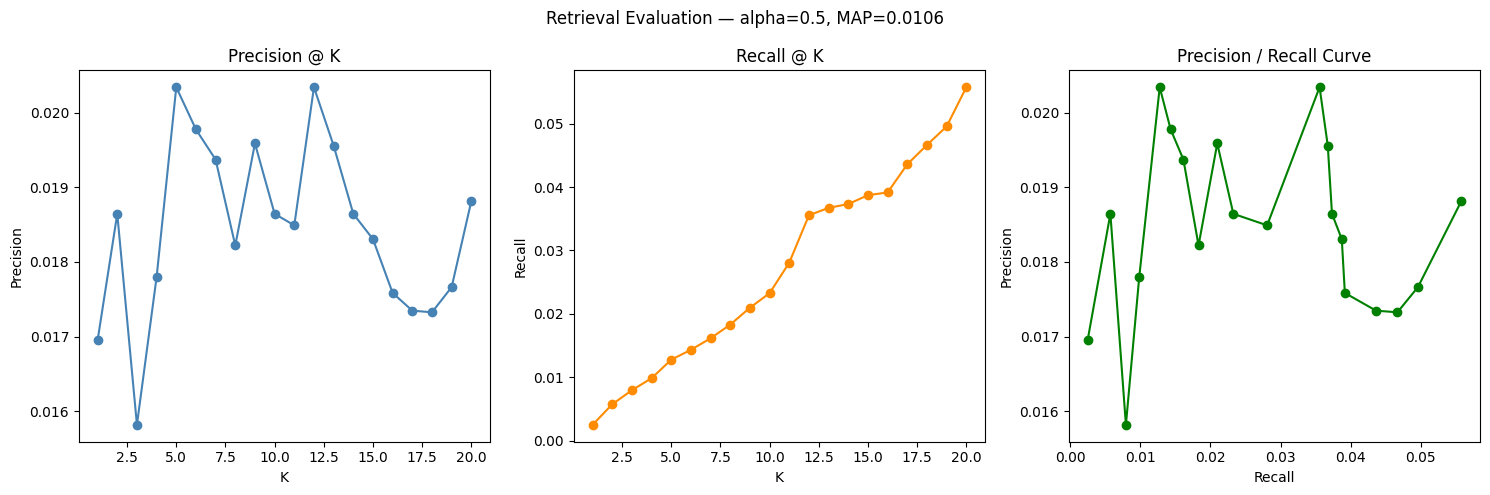

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(metrics_df.index, metrics_df['Precision'], marker='o', color='steelblue')
axes[0].set_title('Precision @ K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision')

axes[1].plot(metrics_df.index, metrics_df['Recall'], marker='o', color='darkorange')
axes[1].set_title('Recall @ K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Recall')


axes[2].plot(metrics_df['Recall'], metrics_df['Precision'], marker='o', color='green')
axes[2].set_title('Precision / Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle(f'Retrieval Evaluation, alpha={0.5}, MAP={np.mean(ap_scores):.4f}')
plt.tight_layout()
plt.show()

## Conclusion - Retrieval Evaluation
Mean Average Precision (MAP) = 0.0106 with median AP = 0.0 indicates that company profile alone (revenue, employees, market cap, volatility, trading volume) **cannot realibly retrieve incidents from the same attack category and industry**.

- Average Precision (AP) for a single query measures: among your top-K retrieved incidents, how early do the relevant ones appear? Our MAP value shows practically none of the queries retrieved relevant results.

- MAP = 0.0106 reflects near-random retrieval: company structural profile provides no signal for identifying incidents of the same attack type and industry.

- Median AP = 0.0 means that for more than half of all queries, not a single relevant incident appeared in the top-20 retrieved

**Why?** Be relevant requires matching both attack vector and industry, recall increasing slowly as k gets bigger suggests the tiny amount of cases falling into the same categories, they being distributed along the more of 300 incidents.

# Conclusion

The recommender system reveals a fundamental property of this dataset: 
cyberattack incidents do not cluster meaningfully by company profile. 
Neither outcome prediction (Part 1) nor structural retrieval (Part 2) 
improves over random foundation when similarity is based on company size 
and market characteristics. This conclusion should be reflected on other techniques as KNN or K-means.

In conclusion, Cyberattacks are not preferentially directed at companies of a particular size or market profile, they are driven by vulnerability, oportunity, and attacker motivation, none of which are captured in financial company data. We would need features describing security posture (training and phylosophy), technology stack, and known vulnerability exposure.